![A soccer pitch for an international match.](soccer-pitch.jpg)

Trabajas como periodista deportivo en una gran empresa de medios deportivos en línea, especializada en análisis e informes de fútbol. Llevas años viendo partidos internacionales de fútbol masculino y femenino, y tu intuición te dice que en los partidos internacionales de fútbol femenino se marcan más goles que en los masculinos. Sería un artículo de investigación interesante que a tus suscriptores les encantará, pero necesitas realizar una prueba estadística de hipótesis válida para estar seguro.

Al definir el alcance de este proyecto, reconoces que el deporte ha cambiado mucho con los años y que el rendimiento probablemente varía bastante según el torneo, así que decides limitar los datos del análisis solo a los partidos oficiales de la `FIFA World Cup` (sin incluir clasificatorios) desde `2002-01-01`.

Has creado dos conjuntos de datos con los resultados de todos los partidos internacionales oficiales de fútbol masculino y femenino desde el siglo XIX, que extrajiste de una fuente confiable en línea. Estos datos están guardados en dos archivos CSV: `women_results.csv` y `men_results.csv`.

La pregunta que quieres responder es:

> ¿Se marcan más goles en los partidos internacionales de fútbol femenino que en los de masculino?

Asume un **nivel de significancia del 10%** y usa las siguientes hipótesis nula y alternativa:

$H_0$ : El número medio de goles en los partidos internacionales de fútbol femenino es el mismo que en los de masculino.

$H_A$ : El número medio de goles en los partidos internacionales de fútbol femenino es mayor que en los de masculino.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44353 non-null  int64 
 1   date        44353 non-null  object
 2   home_team   44353 non-null  object
 3   away_team   44353 non-null  object
 4   home_score  44353 non-null  int64 
 5   away_score  44353 non-null  int64 
 6   tournament  44353 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.4+ MB
   Unnamed: 0        date home_team  ... home_score  away_score  tournament
0           0  1872-11-30  Scotland  ...          0           0    Friendly
1           1  1873-03-08   England  ...          4           2    Friendly
2           2  1874-03-07  Scotland  ...          2           1    Friendly
3           3  1875-03-06   England  ...          2           2    Friendly
4           4  1876-03-04  Scotland  ...          3           0    Friendly

[5 rows x 7 columns]
<cla

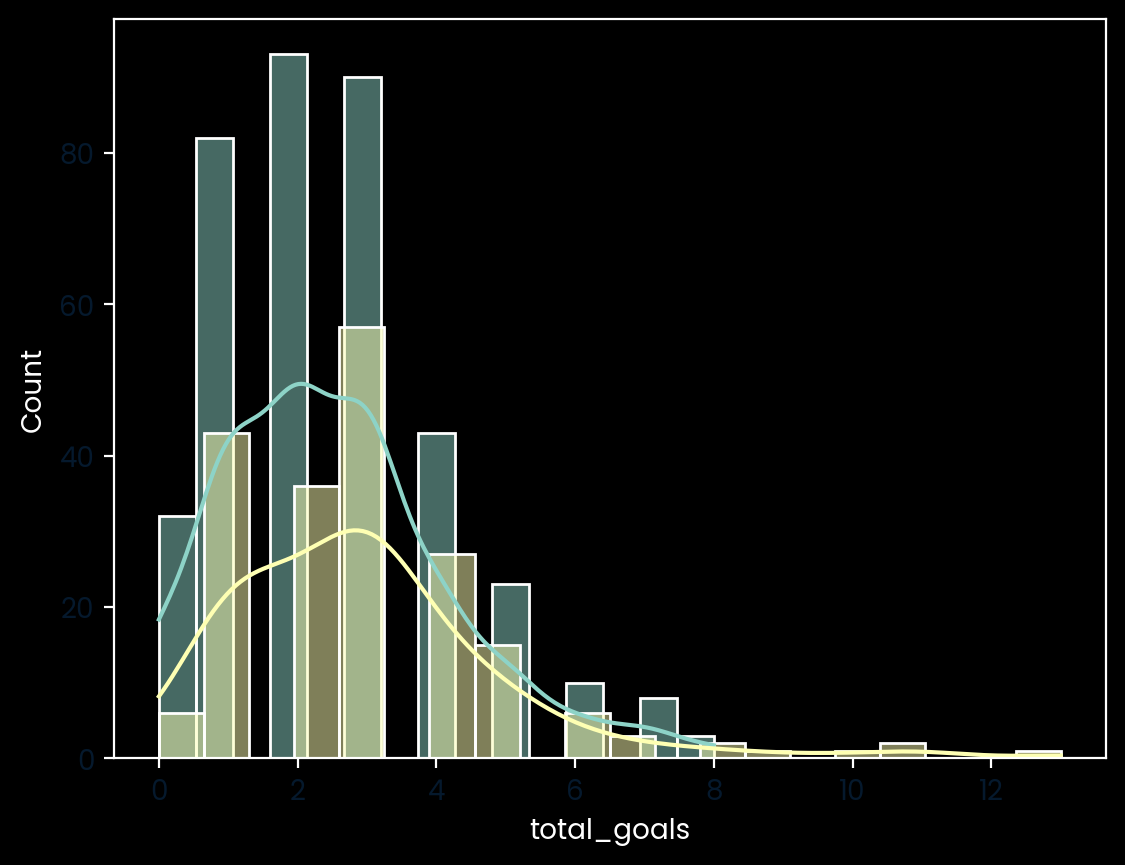

{'p_val': 0.005106609825443641, 'result': 'reject'}
Since the p-value (0.0051) is less than 0.1, we reject the null hypothesis.


In [2]:
# Imports libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import pingouin as pg

# Import datasets
men_results= pd.read_csv('men_results.csv')
women_results= pd.read_csv('women_results.csv')

# Explore Data
men_results.info()
print(men_results.head())

women_results.info()
print(women_results.head())

# Value counts for tournament
tournament= men_results['tournament'].value_counts()

# Filter for FIFA World Cup matches after 2002-01-01
men_fifa = men_results[(men_results['tournament'] == 'FIFA World Cup') & (men_results['date'] >= '2002-01-01')]

women_fifa = women_results[(women_results['tournament'] == 'FIFA World Cup') & (women_results['date'] >= '2002-01-01')]

#determine the type of hypothesis test for the dataset = there are two independent groups, male and female, this case requires an unpaired two-sample t-test.

#An unpaired t-test and a Wilcoxon-Mann-Whitney test are the options, but we need to decide whether to use a parametric or non-parametric test.

#Check if the data is normally distributed using a histogram that shows the distribution of total goals in the matches for both groups, but first add a new column with the total number of goals.
men_fifa['total_goals'] = men_fifa['home_score'] + men_fifa['away_score']
women_fifa['total_goals'] = women_fifa['home_score'] + women_fifa['away_score']

plt.style.use('dark_background')
sns.histplot(data= men_fifa, x='total_goals', kde=True)
sns.histplot(data= women_fifa, x='total_goals', kde=True)
plt.show()

# Now we will confirm that the data is not normally distributed, then we use the Wilcoxon-Mann-Whitney test.
#First create a new dataframe with both groups
men_fifa['group'] = 'men'
women_fifa['group'] = 'women'
both_fifa = pd.concat([men_fifa, women_fifa])

#First use the pivot method to transform the data
both_pivot = both_fifa.pivot(columns='group', values='total_goals')

# Perform the hypothesis test with pingouin
results = pg.mwu(
    x=both_pivot['women'], 
    y=both_pivot['men'], 
    alternative='greater'
)

#Extract the p-value
p_val= results['p-val'].values[0]
result= 'reject'

# Save results in dictionary
result_dict= {"p_val": p_val, 
              "result":result}
print(result_dict)

# Reject the null hypothesis because the p-value is less than 0.1
print(f"Since the p-value ({p_val:.4f}) is less than 0.1, we reject the null hypothesis.")

